# Feature Engineering

Now we transform the raw features into something more useful. The big technique here is **WoE/IV** (Weight of Evidence / Information Value) which is the standard in credit scoring. Also creating some interaction features based on domain knowledge.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_raw_data, get_feature_target
from src.preprocessing import split_data, impute_missing
from src.feature_engineering import (
    calculate_woe_iv, calculate_all_iv, woe_transform,
    create_interaction_features, INTERACTION_FEATURES
)
from src.config import CONFIG

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
df = load_raw_data()
X, y = get_feature_target(df)
X_train, X_test, y_train, y_test = split_data(X, y)
X_train, X_test, imputer = impute_missing(X_train, X_test)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (2400, 28), Test: (600, 28)


## Information Value

IV tells us how predictive each feature is. The standard buckets:
- < 0.02 = useless
- 0.02-0.1 = weak
- 0.1-0.3 = medium
- 0.3-0.5 = strong
- \> 0.5 = suspicious (might be overfitting)

In [3]:
# IV for all features (using training data only!)
train_with_target = X_train.copy()
train_with_target[CONFIG['target_column']] = y_train.values

iv_df = calculate_all_iv(train_with_target, CONFIG['target_column'])
iv_df

,Feature,IV,Strength
0,TLSatPct,0.459284,Strong
1,TLDel60Cnt24,0.424761,Strong
2,TLDel3060Cnt24,0.409954,Strong
3,TLDel60CntAll,0.380124,Strong
4,TLBadDerogCnt,0.330773,Strong
5,TLDel60Cnt,0.293672,Medium
6,TLDel90Cnt24,0.266732,Medium
7,TLBalHCPct,0.250454,Medium
8,InqFinanceCnt24,0.179376,Medium
9,TLBadCnt24,0.161724,Medium


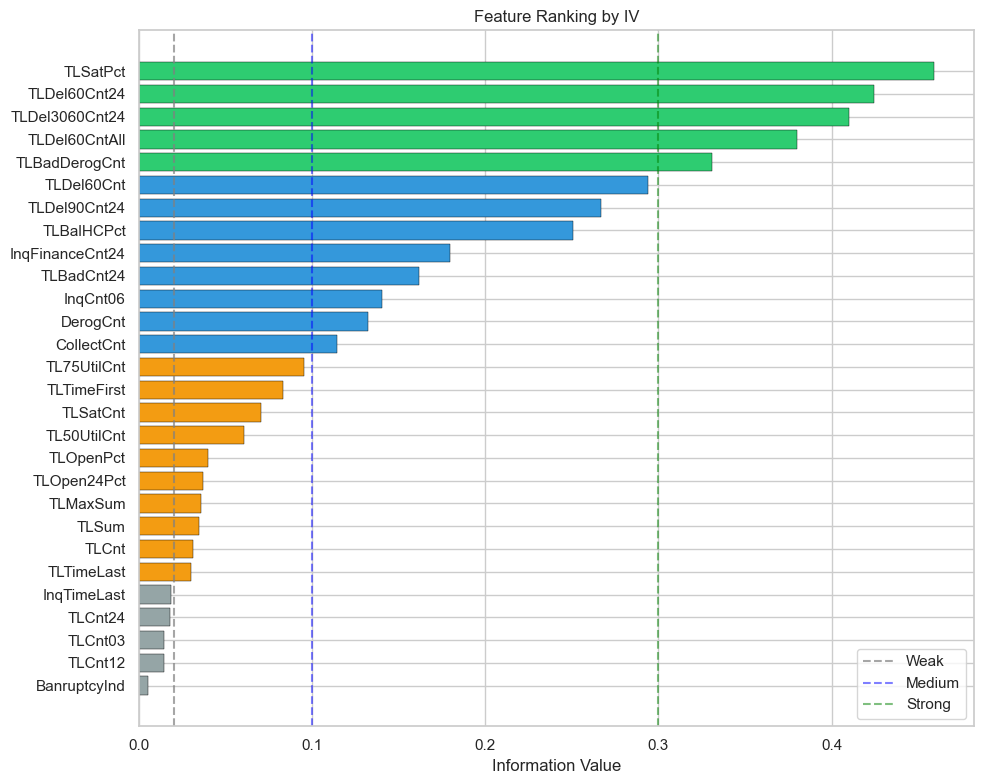

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
colors_map = {'Useless': '#95a5a6', 'Weak': '#f39c12', 'Medium': '#3498db',
              'Strong': '#2ecc71', 'Suspicious': '#e74c3c'}

iv_sorted = iv_df.sort_values('IV', ascending=True)
bar_colors = [colors_map[s] for s in iv_sorted['Strength']]
ax.barh(iv_sorted['Feature'], iv_sorted['IV'], color=bar_colors, edgecolor='black', linewidth=0.3)

ax.axvline(x=0.02, color='gray', linestyle='--', alpha=0.7, label='Weak')
ax.axvline(x=0.1, color='blue', linestyle='--', alpha=0.5, label='Medium')
ax.axvline(x=0.3, color='green', linestyle='--', alpha=0.5, label='Strong')

ax.set_xlabel('Information Value')
ax.set_title('Feature Ranking by IV')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/information_value_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# summary
for strength in ['Strong', 'Medium', 'Weak', 'Useless']:
    feats = iv_df[iv_df['Strength'] == strength]['Feature'].tolist()
    if feats:
        print(f"{strength}: {', '.join(feats)}")

Strong: TLSatPct, TLDel60Cnt24, TLDel3060Cnt24, TLDel60CntAll, TLBadDerogCnt
Medium: TLDel60Cnt, TLDel90Cnt24, TLBalHCPct, InqFinanceCnt24, TLBadCnt24, InqCnt06, DerogCnt, CollectCnt
Weak: TL75UtilCnt, TLTimeFirst, TLSatCnt, TL50UtilCnt, TLOpenPct, TLOpen24Pct, TLMaxSum, TLSum, TLCnt, TLTimeLast
Useless: InqTimeLast, TLCnt24, TLCnt03, TLCnt12, BanruptcyInd


## WoE — detailed look at top features

WoE = ln(% of good in bin / % of bad in bin). Positive = safer, negative = riskier.

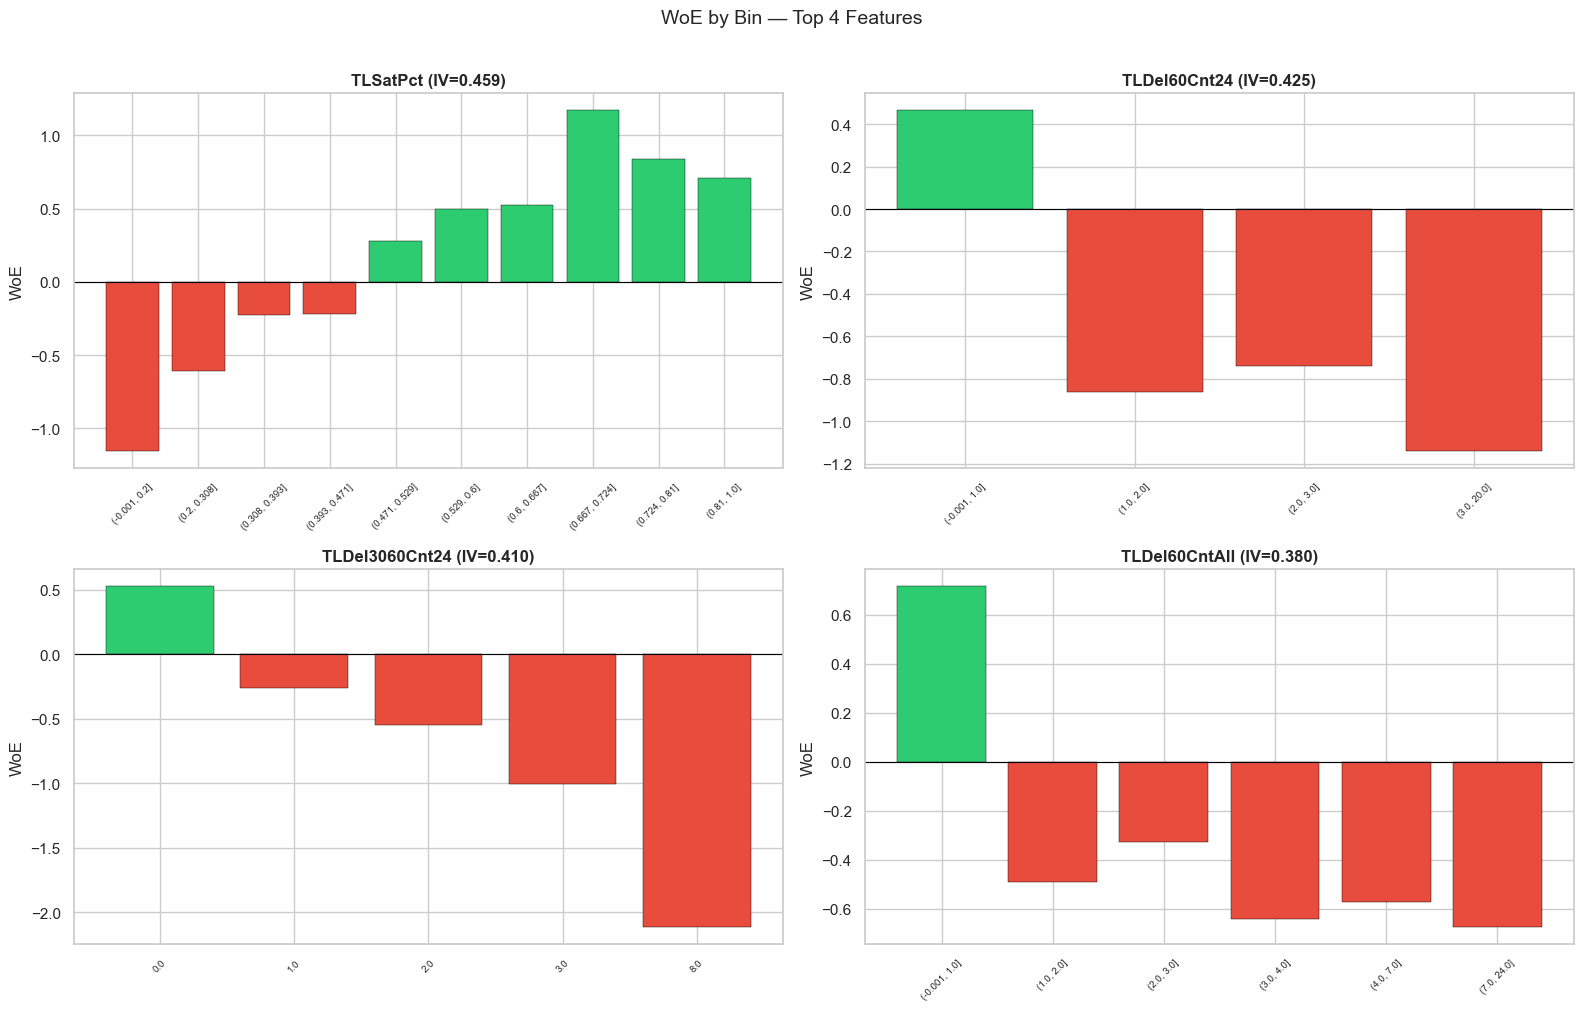

In [6]:
top4 = iv_df.head(4)['Feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top4):
    stats, iv = calculate_woe_iv(train_with_target, feat, CONFIG['target_column'])
    ax = axes[i]
    woe_vals = stats['woe'].values
    c = ['#2ecc71' if w > 0 else '#e74c3c' for w in woe_vals]
    ax.bar(range(len(woe_vals)), woe_vals, color=c, edgecolor='black', linewidth=0.3)
    ax.set_title(f'{feat} (IV={iv:.3f})', fontweight='bold')
    ax.set_ylabel('WoE')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xticks(range(len(woe_vals)))
    ax.set_xticklabels([str(b)[:15] for b in stats.index], rotation=45, fontsize=7)

plt.suptitle('WoE by Bin — Top 4 Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/woe_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

Nice monotonic patterns — exactly what you want to see.

## Interaction features

These are hand-crafted based on credit risk domain knowledge.

In [7]:
X_train_int = create_interaction_features(X_train)
X_test_int = create_interaction_features(X_test)

# do the interactions actually add predictive power?
int_train = X_train_int[INTERACTION_FEATURES].copy()
int_train[CONFIG['target_column']] = y_train.values
int_iv = calculate_all_iv(int_train, CONFIG['target_column'])
print("IV of interaction features:")
print(int_iv.to_string(index=False))

IV of interaction features:
              Feature       IV Strength
   bad_to_total_ratio 0.358803   Strong
 delinquency_severity 0.342312   Strong
    inquiry_intensity 0.222543   Medium
 utilization_pressure 0.212296   Medium
 credit_history_depth 0.084670     Weak
recent_activity_ratio 0.035595     Weak


Some of these are pretty good, some are meh. We'll keep them for the tree models and let feature importance sort it out.

## Feature selection

Dropping useless features (IV < 0.02) and one from each highly correlated pair.

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# drop useless
useless = iv_df[iv_df['IV'] < 0.02]['Feature'].tolist()
print(f"Dropping {len(useless)} useless features: {useless}")

# handle correlated pairs
all_features = iv_df[iv_df['IV'] >= 0.02]['Feature'].tolist()
corr_matrix = X_train[all_features].corr().abs()

drop_cols = set()
iv_lookup = dict(zip(iv_df['Feature'], iv_df['IV']))
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.85:
            f1, f2 = corr_matrix.columns[i], corr_matrix.columns[j]
            drop = f2 if iv_lookup.get(f1, 0) >= iv_lookup.get(f2, 0) else f1
            drop_cols.add(drop)
            print(f"  {f1} <-> {f2} (r={corr_matrix.iloc[i,j]:.2f}) -> drop {drop}")

selected_features = [f for f in all_features if f not in drop_cols]
print(f"\nKept {len(selected_features)} out of {len(X_train.columns)} original features")

Dropping 5 useless features: ['InqTimeLast', 'TLCnt24', 'TLCnt03', 'TLCnt12', 'BanruptcyInd']
  TLDel60Cnt24 <-> TLDel90Cnt24 (r=0.95) -> drop TLDel90Cnt24
  TLDel60CntAll <-> TLDel60Cnt (r=0.89) -> drop TLDel60Cnt
  TLDel90Cnt24 <-> TLBadCnt24 (r=0.91) -> drop TLBadCnt24
  DerogCnt <-> CollectCnt (r=0.86) -> drop CollectCnt
  TL75UtilCnt <-> TL50UtilCnt (r=0.93) -> drop TL50UtilCnt
  TLSatCnt <-> TLCnt (r=0.86) -> drop TLCnt
  TLMaxSum <-> TLSum (r=0.89) -> drop TLSum

Kept 16 out of 28 original features


In [9]:
# VIF as a sanity check
X_vif = X_train[selected_features].copy()
vif_data = pd.DataFrame({
    'Feature': selected_features,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(selected_features))]
}).sort_values('VIF', ascending=False)

print("VIF (>10 is bad):")
print(vif_data.to_string(index=False))

VIF (>10 is bad):
        Feature       VIF
       TLSatPct 15.794397
      TLOpenPct 12.891761
       TLSatCnt  9.063557
  TLBadDerogCnt  8.197034
   TLDel60Cnt24  7.893014
     TLBalHCPct  7.271542
    TLTimeFirst  4.822125
       TLMaxSum  4.791541
    TL75UtilCnt  4.591533
  TLDel60CntAll  3.820486
       InqCnt06  3.646816
InqFinanceCnt24  3.615174
       DerogCnt  3.545201
    TLOpen24Pct  3.287947
 TLDel3060Cnt24  2.115313
     TLTimeLast  1.709838


In [10]:
# save everything for the modeling notebooks
import os
os.makedirs('../data/processed', exist_ok=True)

# full features (with interactions) — for tree models
X_train_full = create_interaction_features(X_train)
X_test_full = create_interaction_features(X_test)
X_train_full.to_parquet('../data/processed/X_train_full.parquet')
X_test_full.to_parquet('../data/processed/X_test_full.parquet')
y_train.to_frame().to_parquet('../data/processed/y_train.parquet')
y_test.to_frame().to_parquet('../data/processed/y_test.parquet')

# WoE transformed — for logistic regression + scorecard
X_train_woe, X_test_woe, woe_maps = woe_transform(X_train, X_test, y_train)
X_train_woe.to_parquet('../data/processed/X_train_woe.parquet')
X_test_woe.to_parquet('../data/processed/X_test_woe.parquet')

pd.Series(selected_features, name='feature').to_csv(
    '../data/processed/selected_features.csv', index=False)

print(f"Saved. Full: {X_train_full.shape[1]} cols, WoE: {X_train_woe.shape[1]} cols, Selected: {len(selected_features)}")

Saved. Full: 34 cols, WoE: 28 cols, Selected: 16
